## Importações

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

# years = [2019, 2020, 2021, 2022, 2023, 2024]
years = range(2019,2025)

# modes = {}
# graphs = {}

# base_modes = "../../data/03_modes"

# for year in years:
#     for speed in ["fast", "medium", "slow"]:
#         file_path = f"../../data/04_graphs/{year}/{speed}_graph.gpickle"
#         with open(file_path, "rb") as f:
#             graphs[f"graph_{speed}_{year}"] = pickle.load(f)
                    
#             modes[f"{speed}_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/{speed}_emd.parquet")

graphs = {}
returns = {}

base_modes = "../../data/02_clean"
k = 1

for year in years:
    file_path = f"../../data/04_graphs/{year}_{k}/graph.gpickle"
    with open(file_path, "rb") as f:
        graphs[f"graph_{year}"] = pickle.load(f)
                
        returns[year] = pd.read_parquet(f"../../data/02_clean/returns_{year}.parquet")
        returns[year] = np.log(1 + returns[year])

## Funções

In [12]:
import community as community_louvain

def calculate_hybrid_risk_metric(G, weights=None):
    # Default equal weights if not provided
    if weights is None:
        weights = {
            'degree': 1/3,
            'closeness': 1/3,
            'betweenness': 0,
            'eigenvector': 1/3
        }
    
    nodes = list(G.nodes)

    G = G.copy()
    for u, v, d in G.edges(data=True):
        d["distance"] = 1 / abs(d["weight"]) if d["weight"] != 0 else np.inf
    
    # 1. Calculate raw metrics
    
    # Degree
    degree_dict = dict(nx.degree(G, weight="weight"))
    
    # Clustering coefficient
    closeness_dict = nx.closeness_centrality(G, distance="distance")
    
    # Betweenness centrality
    betweenness_dict = nx.betweenness_centrality(G, weight='distance', normalized=True)
    
    # Eigenvector centrality
    eig_dict = nx.eigenvector_centrality(G, weight="weight")
    
    # 2. Normalize metrics (0=lowest risk, 1=highest risk)
    def normalize_dict(d, invert=False):
        vals = np.array(list(d.values()))
        min_val = vals.min()
        max_val = vals.max()
        if max_val - min_val == 0:
            # Avoid division by zero if all values equal
            return {k: 0.0 for k in d.keys()}
        norm = {k: (v - min_val) / (max_val - min_val) for k, v in d.items()}
        if invert:
            norm = {k: 1 - v for k, v in norm.items()}
        return norm
    
    norm_degree = normalize_dict(degree_dict, invert=False)
    norm_closeness = normalize_dict(closeness_dict, invert=False)
    norm_betweenness = normalize_dict(betweenness_dict, invert=False)
    norm_eig = normalize_dict(eig_dict, invert=False)
    
    # 3. Combine metrics with weights
    risk_scores = {}
    for node in nodes:
        score = (
            weights['degree'] * norm_degree[node] +
            weights['closeness'] * norm_closeness[node] +
            weights['betweenness'] * norm_betweenness[node] +
            weights['eigenvector'] * norm_eig[node] 
        )
        risk_scores[node] = score
    
    return risk_scores

## Construção do DataFrame com os nós e as métricas de grafos calculadas para cada modo

In [13]:
for name, G in graphs.items():
    print(name)

graph_2019
graph_2020
graph_2021
graph_2022
graph_2023
graph_2024


In [14]:
data = []

for name, G in graphs.items():
    _, year = name.split("_")

    G = G.copy()
    for u, v, d in G.edges(data=True):
        d["distance"] = 1 / abs(d["weight"]) if d["weight"] != 0 else np.inf

    hrm = calculate_hybrid_risk_metric(G)
    degree_dict = dict(nx.degree(G, weight="weight"))
    closeness_dict = nx.closeness_centrality(G, distance="distance")
    betweenness_dict = nx.betweenness_centrality(G, weight='distance', normalized=True)
    eig_dict = nx.eigenvector_centrality(G, weight="weight")

    for node in G.nodes():
        data.append({
            "node": node,
            "hrm": hrm[node],
            "degree": degree_dict[node],
            "closeness": closeness_dict[node],
            "eig": eig_dict[node],
            "year": year
        })

df = pd.DataFrame(data)

In [15]:
central_portfolios = {}
peripheral_portfolios = {}

q75 = df.groupby("year")["hrm"].quantile(0.80).reset_index(name="p75")
q25 = df.groupby("year")["hrm"].quantile(0.20).reset_index(name="p25")

for year in years:
    p75 = q75.loc[q75["year"] == str(year), "p75"].iloc[0]
    p25 = q25.loc[q25["year"] == str(year), "p25"].iloc[0]

    central_portfolios[year] = df[(df["year"] == str(year)) & (df["hrm"] > p75)]
    peripheral_portfolios[year] = df[(df["year"] == str(year)) & (df["hrm"] < p25)]

In [16]:
centralities = ["central", "peripheral"]

def get_portfolio_info(
        portfolio
):
    stock_info = pd.read_csv("../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv")
    screener = pd.read_parquet("../../data/01_raw/screener_result.parquet")[["Ticker", "Country"]]
    stock_info = stock_info.merge(
        screener,
        how="left",
        on="Ticker"
    )
    portfolio = portfolio.to_frame().rename(columns={"node":"Ticker"})
    return portfolio.merge(
        stock_info, on="Ticker", how="left"
    )

for year in years:
    central_temp = central_portfolios[year]["node"]
    peripheral_temp = peripheral_portfolios[year]["node"]
    returns_temp = pd.read_parquet(
        f"../../data/02_clean/returns_{year}.parquet"
    )
    central_port_temp = returns_temp[central_temp]
    peripheral_port_temp = returns_temp[peripheral_temp]

    central_metadata_temp = get_portfolio_info(central_temp)
    peripheral_metadata_temp = get_portfolio_info(peripheral_temp)

    central_port_temp.to_csv(f"../../data/06_portfolios/central_{year}_{k}.csv")
    peripheral_port_temp.to_csv(f"../../data/06_portfolios/peripheral_{year}_{k}.csv")

    central_metadata_temp.to_csv(f"../../data/07_portfolios_metadata/central_metadata_{year}_{k}.csv")
    peripheral_metadata_temp.to_csv(f"../../data/07_portfolios_metadata/peripheral_metadata_{year}_{k}.csv")

### Analysis of metrics

In [17]:
df = df.merge(pd.read_csv("../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv")[["Ticker", "Sector"]],
         left_on="node", right_on="Ticker", how="inner")

In [18]:
# # --- 1. Sort and compute % change in HRM score per stock year-over-year ---
# df_sorted = df[["Ticker", "Sector", "year", "hrm"]].sort_values(["Ticker", "year"])

# df_sorted["hrm_pct_change"] = (
#     df_sorted.groupby("Ticker")["hrm"]
#     .pct_change()
#     .replace([np.inf, -np.inf], np.nan)  # ← treat as missing, excluded from mean
#     .mul(100)
# )

# # Drop first year (no previous value)
# df_shifted = df_sorted.dropna(subset=["hrm_pct_change"])

# # --- 2. Average % change per sector/year ---
# avg_pct = (
#     df_shifted.groupby(["Sector", "year"])["hrm_pct_change"]
#     .median()
#     .reset_index()
#     .rename(columns={"hrm_pct_change": "avg_pct_change"})
# )

# pivot = avg_pct.pivot(index="Sector", columns="year", values="avg_pct_change")

# # --- 3. Plot ---
# sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# fig, ax = plt.subplots(figsize=(14, 6))

# # Diverging colormap: red = declined, blue = increased
# abs_max = np.nanpercentile(np.abs(pivot.values), 95)  # robust symmetric scale

# sns.heatmap(
#     pivot,
#     ax=ax,
#     annot=True,
#     fmt=".1f",
#     cmap="Blues",
#     center=0,
#     vmin=-abs_max, vmax=abs_max,
#     linewidths=0.4,
#     linecolor="white",
#     cbar_kws={"shrink": 0.8},
#     annot_kws={"fontsize": 8}
# )

# ax.set_title(
#     "Median % Change in Hybrid Centrality Metric Score",
#     fontsize=12, fontweight="bold", pad=10
# )
# ax.set_xlabel("Year", fontsize=10)
# ax.set_ylabel("Sector", fontsize=10)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# plt.tight_layout()
# os.makedirs(f"../../figures/window_{k}/", exist_ok=True)
# plt.savefig(f"../../figures/window_{k}/median_change_hrm.png")
# plt.show()

In [19]:
final_df = pd.read_csv("../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv")
beta_momentum = pd.read_csv("../../data/07_portfolios_metadata/beta_momentum.csv", index_col="Unnamed: 0")

final_df = final_df.merge(beta_momentum, on="Ticker", how="inner")

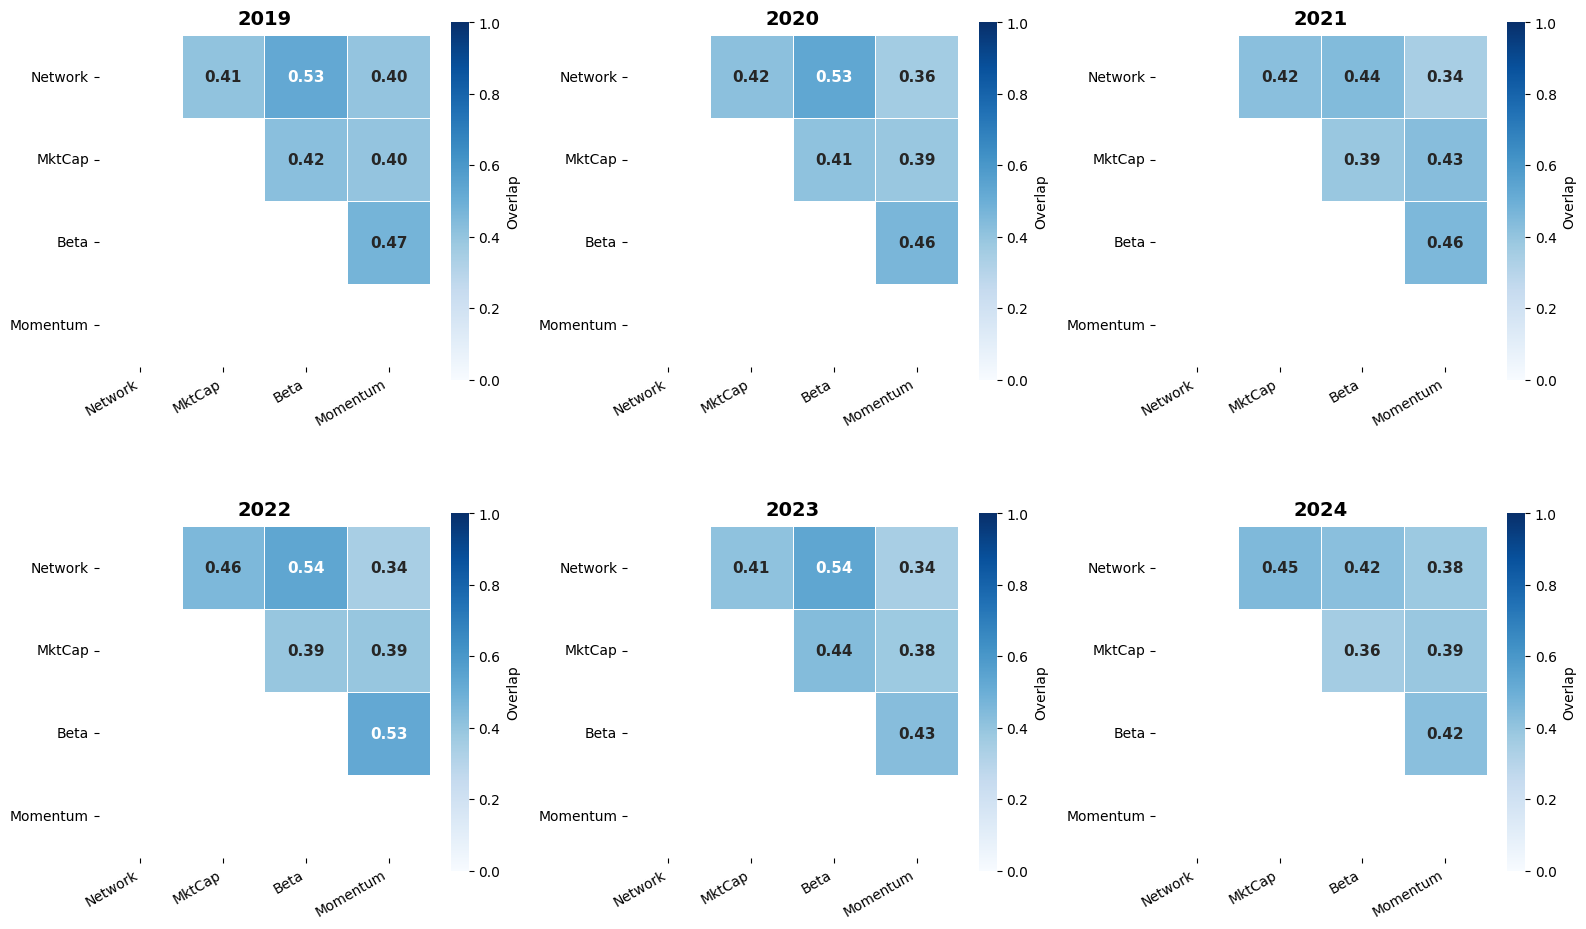

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

years = list(range(2019, 2025))
N = 80  # top + bottom stocks for metric portfolios

# --- helpers ---
def get_network_stocks(year):
    central   = set(central_portfolios[year]["node"])   if year in central_portfolios   else set()
    peripheral = set(peripheral_portfolios[year]["node"]) if year in peripheral_portfolios else set()
    return central | peripheral

def get_metric_stocks(col_pattern, year, n=N):
    col = col_pattern.format(year=year)
    if col not in final_df.columns:
        return set()
    s = final_df.dropna(subset=[col]).sort_values(col, ascending=False)
    return set(s.iloc[:n]["Ticker"]) | set(s.iloc[-n:]["Ticker"])

def overlap_coef(a, b):
    denom = min(len(a), len(b))
    return len(a & b) / denom if denom > 0 else 0.0

# column name patterns — adjust if yours differ
col_patterns = {
    "MktCap":   "mcap_{year}",
    "Beta":     "beta_{year}",
    "Momentum": "momentum_{year}",
}

labels = ["Network", "MktCap", "Beta", "Momentum"]

# --- one subplot per year ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, year in zip(axes, years):
    # build portfolio sets for this year
    portfolios = {
        "Network":  get_network_stocks(year),
        "MktCap":   get_metric_stocks(col_patterns["MktCap"],   year),
        "Beta":     get_metric_stocks(col_patterns["Beta"],     year),
        "Momentum": get_metric_stocks(col_patterns["Momentum"], year),
    }

    # build 4x4 overlap matrix
    mat = pd.DataFrame(index=labels, columns=labels, dtype=float)
    for r in labels:
        for c in labels:
            mat.loc[r, c] = overlap_coef(portfolios[r], portfolios[c])

    mask = np.tril(np.ones_like(mat, dtype=bool))

    sns.heatmap(
        mat.astype(float),
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor="white",
        square=True,
        mask=mask,
        cbar_kws={"shrink": 0.8, "label": "Overlap"},
        annot_kws={"size": 11, "weight": "bold"},
    )
    ax.set_title(str(year), fontsize=14, fontweight="bold", pad=8)
    ax.tick_params(axis="both", labelsize=10)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels, rotation=0)

# fig.suptitle("Overlap Coefficients Between Portfolio Strategies (2019–2024)",
#              fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"../../figures/window_{k}/overlap_heatmaps_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

In [91]:
network_stocks = {}
mcap_stocks = {}
beta_stocks = {}
momentum_stocks = {}
dr = {}
cr = {}

for year in years:
    network_stocks[year] = list(get_network_stocks(year))
    mcap_stocks[year] = list(get_metric_stocks(f"mcap_{year}", year))
    beta_stocks[year] = list(get_metric_stocks(f"beta_{year}", year))
    momentum_stocks[year] = list(get_metric_stocks(f"momentum_{year}", year))

In [92]:
returns_all = pd.concat(
    [
        pd.read_parquet(f"../../data/02_clean/returns_{year+1}.parquet")
        for year in years
    ],
    axis=0
).sort_index()

weights = pd.DataFrame(
    0.0,
    index=returns_all.index,
    columns=returns_all.columns
)

for year in years:
    year_idx = returns_all.loc[str(year+1)].index
    stocks = returns_all.columns.intersection(network_stocks[year])

    if len(stocks) > 0:
        weights.loc[year_idx, stocks] = 1 / len(stocks)

portfolio_returns = (weights * returns_all).sum(axis=1)

turnover = weights.diff().abs().sum(axis=1) / 2

cost = 0.002

net_returns = portfolio_returns - turnover * cost
cum_returns = (1 + net_returns).cumprod()
cum_returns = cum_returns / cum_returns.iloc[0]

dr["network"] = net_returns 
cr["network"] = cum_returns

In [93]:
returns_all = pd.concat(
    [
        pd.read_parquet(f"../../data/02_clean/returns_{year+1}.parquet")
        for year in years
    ],
    axis=0
).sort_index()

weights = pd.DataFrame(
    0.0,
    index=returns_all.index,
    columns=returns_all.columns
)

for year in years:
    year_idx = returns_all.loc[str(year+1)].index
    stocks = returns_all.columns.intersection(mcap_stocks[year])

    if len(stocks) > 0:
        weights.loc[year_idx, stocks] = 1 / len(stocks)

portfolio_returns = (weights * returns_all).sum(axis=1)

turnover = weights.diff().abs().sum(axis=1) / 2

cost = 0.002

net_returns = portfolio_returns - turnover * cost
cum_returns = (1 + net_returns).cumprod()
cum_returns = cum_returns / cum_returns.iloc[0]

dr["mcap"] = net_returns 
cr["mcap"] = cum_returns

In [94]:
returns_all = pd.concat(
    [
        pd.read_parquet(f"../../data/02_clean/returns_{year+1}.parquet")
        for year in years
    ],
    axis=0
).sort_index()

weights = pd.DataFrame(
    0.0,
    index=returns_all.index,
    columns=returns_all.columns
)

for year in years:
    year_idx = returns_all.loc[str(year+1)].index
    stocks = returns_all.columns.intersection(beta_stocks[year])

    if len(stocks) > 0:
        weights.loc[year_idx, stocks] = 1 / len(stocks)

portfolio_returns = (weights * returns_all).sum(axis=1)

turnover = weights.diff().abs().sum(axis=1) / 2

cost = 0.002

net_returns = portfolio_returns - turnover * cost
cum_returns = (1 + net_returns).cumprod()
cum_returns = cum_returns / cum_returns.iloc[0]

dr["beta"] = net_returns 
cr["beta"] = cum_returns

In [95]:
returns_all = pd.concat(
    [
        pd.read_parquet(f"../../data/02_clean/returns_{year+1}.parquet")
        for year in years
    ],
    axis=0
).sort_index()

weights = pd.DataFrame(
    0.0,
    index=returns_all.index,
    columns=returns_all.columns
)

for year in years:
    year_idx = returns_all.loc[str(year+1)].index
    stocks = returns_all.columns.intersection(momentum_stocks[year])

    if len(stocks) > 0:
        weights.loc[year_idx, stocks] = 1 / len(stocks)

portfolio_returns = (weights * returns_all).sum(axis=1)

turnover = weights.diff().abs().sum(axis=1) / 2

cost = 0.002

net_returns = portfolio_returns - turnover * cost
cum_returns = (1 + net_returns).cumprod()
cum_returns = cum_returns / cum_returns.iloc[0]

dr["momentum"] = net_returns 
cr["momentum"] = cum_returns

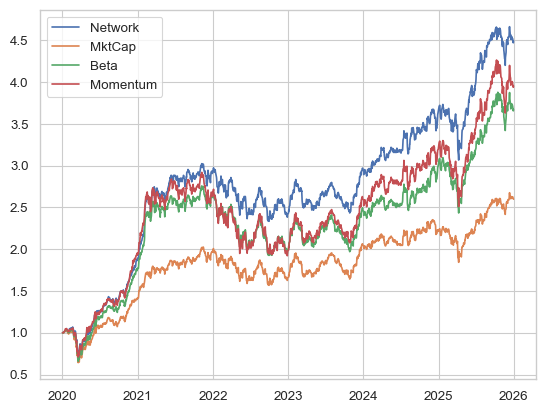

In [96]:
plt.plot(cr["network"], label="Network")
plt.plot(cr["mcap"], label="MktCap")
plt.plot(cr["beta"], label="Beta")
plt.plot(cr["momentum"], label="Momentum")

plt.legend()
plt.show()